# Analyse des performances — Prompt 1 (Baseline)

Ce notebook analyse les résultats d'évaluation Prompt 1 (Entailment vs Contradiction) à partir des CSV générés pour les jeux **POL**, **MEDICAL** et **Combined**. Les analyses s'appuient sur le **macro F1 score** entre les deux labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import os
from sklearn.metrics import f1_score, confusion_matrix, classification_report

def macro_f1(y_true, y_pred):
    """Macro F1 entre les labels Entailment et Contradiction."""
    return f1_score(y_true, y_pred, labels=["Contradiction", "Entailment"], average="macro")

# Dossier des CSV et JSONL (même dossier que ce notebook)
RESULTS_DIR = "."
GRAPHS_DIR = os.path.join(RESULTS_DIR, "graphes")
os.makedirs(GRAPHS_DIR, exist_ok=True)
df_combined = pd.read_csv(os.path.join(RESULTS_DIR, "eval_nli_combined_baseline.csv"))
df_pol = pd.read_csv(os.path.join(RESULTS_DIR, "eval_nli_pol_baseline.csv"))
df_medical = pd.read_csv(os.path.join(RESULTS_DIR, "eval_nli_medical_baseline.csv"))
print("Combined:", df_combined.shape, "| POL:", df_pol.shape, "| MEDICAL:", df_medical.shape)
df_combined.head()

Combined: (3156, 5) | POL: (1578, 4) | MEDICAL: (1578, 4)


,index,statement_type,gold,prediction,is_correct
0,0,pol,Entailment,Contradiction,False
1,1,pol,Contradiction,Entailment,False
2,2,pol,Entailment,Entailment,True
3,3,pol,Contradiction,Contradiction,True
4,4,pol,Contradiction,Contradiction,True


---
## 1. Analyse globale (fichier Combined)

Métriques générales sur l'ensemble des données combinées : **Macro F1 score** (Entailment / Contradiction), puis **matrice de confusion** (Prédictions vs Vrais labels).

In [2]:
# Métriques globales (Combined)
y_true = df_combined["gold"]
y_pred = df_combined["prediction"]
f1_global = macro_f1(y_true, y_pred)
print("=== Métriques globales (Combined) ===")
print(f"Macro F1 : {f1_global:.4f}")
print(classification_report(y_true, y_pred, target_names=["Contradiction", "Entailment"]))

=== Métriques globales (Combined) ===
Macro F1 : 0.5245
               precision    recall  f1-score   support

Contradiction       0.50      0.93      0.65      1382
   Entailment       0.84      0.26      0.40      1774

     accuracy                           0.56      3156
    macro avg       0.67      0.60      0.52      3156
 weighted avg       0.69      0.56      0.51      3156



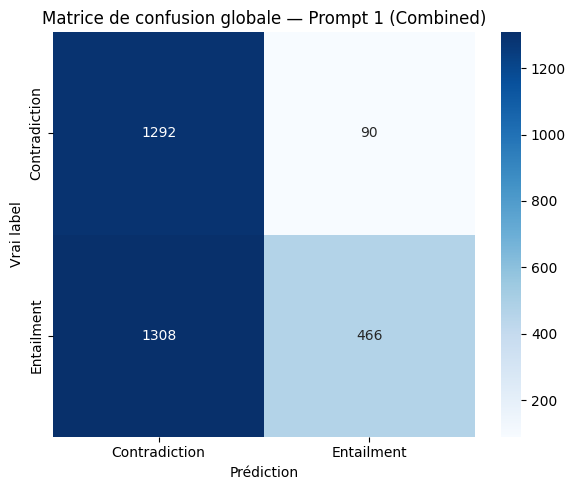

In [3]:
# Matrice de confusion globale
cm_global = confusion_matrix(y_true, y_pred, labels=["Contradiction", "Entailment"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_global, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Contradiction", "Entailment"],
            yticklabels=["Contradiction", "Entailment"])
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vrai label")
ax.set_title("Matrice de confusion globale — Prompt 1 (Combined)")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_confusion_combined.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Analyse comparative (POL vs MEDICAL)

Séparation des résultats par type de langage : **Macro F1** distinct par sous-groupe et deux matrices de confusion.

In [4]:
# Séparation par statement_type
df_pol_sub = df_combined[df_combined["statement_type"] == "pol"]
df_medical_sub = df_combined[df_combined["statement_type"] == "medical"]

# Macro F1 par sous-groupe
f1_pol = macro_f1(df_pol_sub["gold"], df_pol_sub["prediction"])
f1_medical = macro_f1(df_medical_sub["gold"], df_medical_sub["prediction"])

print("=== POL ===")
print(f"  Macro F1 : {f1_pol:.4f}")
print("\n=== MEDICAL ===")
print(f"  Macro F1 : {f1_medical:.4f}")
print("\n=== Synthèse ===")
pd.DataFrame({
    "Macro F1": [f1_pol, f1_medical]
}, index=["POL", "MEDICAL"])

=== POL ===
  Macro F1 : 0.4965

=== MEDICAL ===
  Macro F1 : 0.5510

=== Synthèse ===


,Macro F1
POL,0.496532
MEDICAL,0.550956


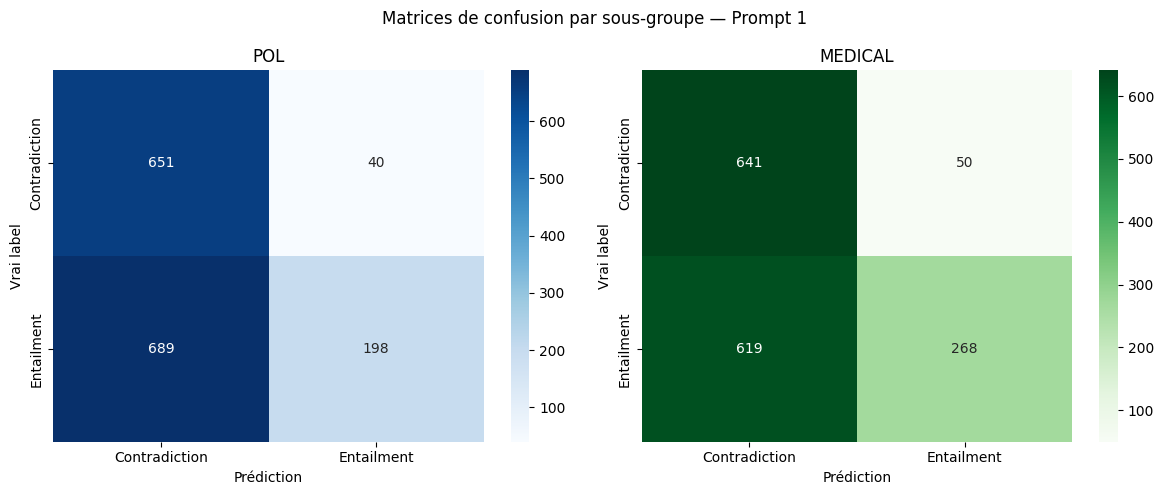

In [5]:
# Matrices de confusion POL et MEDICAL
cm_pol = confusion_matrix(df_pol_sub["gold"], df_pol_sub["prediction"], labels=["Contradiction", "Entailment"])
cm_medical = confusion_matrix(df_medical_sub["gold"], df_medical_sub["prediction"], labels=["Contradiction", "Entailment"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_cm = ["Contradiction", "Entailment"]
sns.heatmap(cm_pol, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels_cm, yticklabels=labels_cm)
axes[0].set_xlabel("Prédiction"); axes[0].set_ylabel("Vrai label"); axes[0].set_title("POL")
sns.heatmap(cm_medical, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=labels_cm, yticklabels=labels_cm)
axes[1].set_xlabel("Prédiction"); axes[1].set_ylabel("Vrai label"); axes[1].set_title("MEDICAL")
plt.suptitle("Matrices de confusion par sous-groupe — Prompt 1")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_confusion_pol_medical.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Macro F1 selon la taille du prompt

Découpage des prompts en **Petit**, **Moyen**, **Grand** (longueur en mots). Bar plot : **Macro F1** globale selon ces trois tailles.

Les textes des prompts sont chargés depuis les JSONL de test (`nli_test_pol.jsonl`, `nli_test_medical.jsonl`).

In [6]:
def load_prompt_lengths_from_jsonl(jsonl_path):
    """Charge les lignes du JSONL et retourne pour chaque index le nombre de mots du prompt (Premise + Hypothesis)."""
    lengths = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            user_content = next(m["content"] for m in obj["messages"] if m["role"] == "user")
            n_words = len(user_content.split())
            lengths.append(n_words)
    return np.array(lengths)

# Chargement des longueurs (test set)
path_pol = os.path.join(RESULTS_DIR, "nli_test_pol.jsonl")
path_medical = os.path.join(RESULTS_DIR, "nli_test_medical.jsonl")
lengths_pol = load_prompt_lengths_from_jsonl(path_pol) if os.path.exists(path_pol) else None
lengths_medical = load_prompt_lengths_from_jsonl(path_medical) if os.path.exists(path_medical) else None
print("Longueurs POL (mots) - min/med/max:", lengths_pol.min(), np.median(lengths_pol), lengths_pol.max() if lengths_pol is not None else "N/A")
print("Longueurs MEDICAL (mots) - min/med/max:", lengths_medical.min(), np.median(lengths_medical), lengths_medical.max() if lengths_medical is not None else "N/A")

Longueurs POL (mots) - min/med/max: 39 279.0 2141
Longueurs MEDICAL (mots) - min/med/max: 105 266.5 2097


In [7]:
# Catégorisation par taille (toutes longueurs confondues pour définir les seuils)
all_lengths = np.concatenate([lengths_pol, lengths_medical]) if lengths_pol is not None and lengths_medical is not None else np.array([])
if len(all_lengths) > 0:
    q33, q66 = np.percentile(all_lengths, [33, 66])
    def size_category(n_words):
        if n_words <= q33: return "Petit"
        if n_words <= q66: return "Moyen"
        return "Grand"
else:
    def size_category(n_words):
        if n_words <= 200: return "Petit"
        if n_words <= 400: return "Moyen"
        return "Grand"
    q33, q66 = 200, 400
print(f"Seuils utilisés : Petit ≤ {q33:.0f} mots, Moyen ≤ {q66:.0f} mots, Grand > {q66:.0f} mots")

Seuils utilisés : Petit ≤ 220 mots, Moyen ≤ 346 mots, Grand > 346 mots


In [8]:
# Associer taille du prompt aux résultats Combined (index = ligne dans le JSONL pour pol puis medical)
df_combined_with_size = df_combined.copy()
sizes = []
for _, row in df_combined.iterrows():
    idx = row["index"]
    stype = row["statement_type"]
    arr = lengths_pol if stype == "pol" else lengths_medical
    if arr is not None and idx < len(arr):
        sizes.append(size_category(arr[idx]))
    else:
        sizes.append("Moyen")  # fallback
df_combined_with_size["size_category"] = sizes
# Macro F1 par taille du prompt
def macro_f1_group(g):
    return macro_f1(g["gold"], g["prediction"])
f1_by_size = df_combined_with_size.groupby("size_category").apply(macro_f1_group).reindex(["Petit", "Moyen", "Grand"])
count_by_size = df_combined_with_size.groupby("size_category").size().reindex(["Petit", "Moyen", "Grand"])
acc_by_size = pd.DataFrame({"macro_f1": f1_by_size, "count": count_by_size})
acc_by_size

C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_23828\1435969965.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  f1_by_size = df_combined_with_size.groupby("size_category").apply(macro_f1_group).reindex(["Petit", "Moyen", "Grand"])


,macro_f1,count
size_category,,
Petit,0.518574,1047
Moyen,0.549951,1039
Grand,0.503636,1070


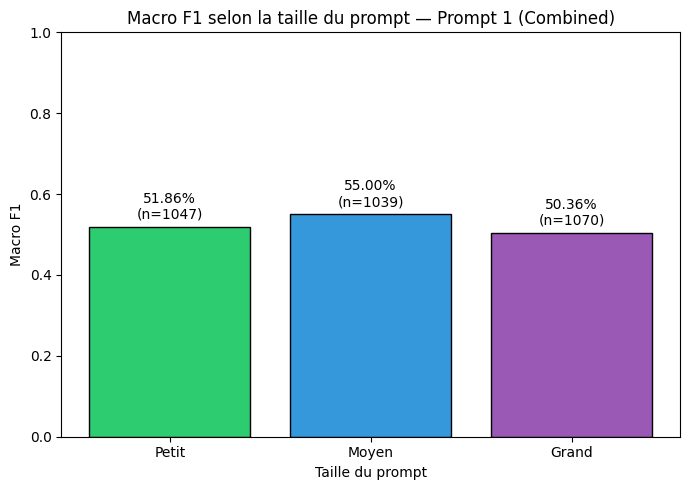

In [9]:
# Bar plot : Macro F1 selon la taille du prompt
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(acc_by_size))
ax.bar(x, acc_by_size["macro_f1"], color=["#2ecc71", "#3498db", "#9b59b6"], edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(acc_by_size.index)
ax.set_ylabel("Macro F1")
ax.set_xlabel("Taille du prompt")
ax.set_title("Macro F1 selon la taille du prompt — Prompt 1 (Combined)")
ax.set_ylim(0, 1)
for i, (f1, cnt) in enumerate(zip(acc_by_size["macro_f1"], acc_by_size["count"])):
    ax.text(i, f1 + 0.02, f"{f1:.2%}\n(n={cnt})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_macro_f1_par_taille.png"), dpi=150, bbox_inches="tight")
plt.show()

---
### 3 bis. Détail de la taille par sous-groupe (POL vs MEDICAL)

Pour chaque catégorie de taille (Petit, Moyen, Grand), deux barres juxtaposées : **Macro F1** **POL** vs **MEDICAL**.

In [10]:
# Macro F1 par (size_category, statement_type)
acc_by_size_type = df_combined_with_size.groupby(["size_category", "statement_type"]).apply(macro_f1_group).unstack(fill_value=0)
acc_by_size_type = acc_by_size_type.reindex(["Petit", "Moyen", "Grand"])
acc_by_size_type

C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_23828\765935786.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_size_type = df_combined_with_size.groupby(["size_category", "statement_type"]).apply(macro_f1_group).unstack(fill_value=0)


statement_type,medical,pol
size_category,,
Petit,0.575950,0.445245
Moyen,0.558699,0.541315
Grand,0.511041,0.496713


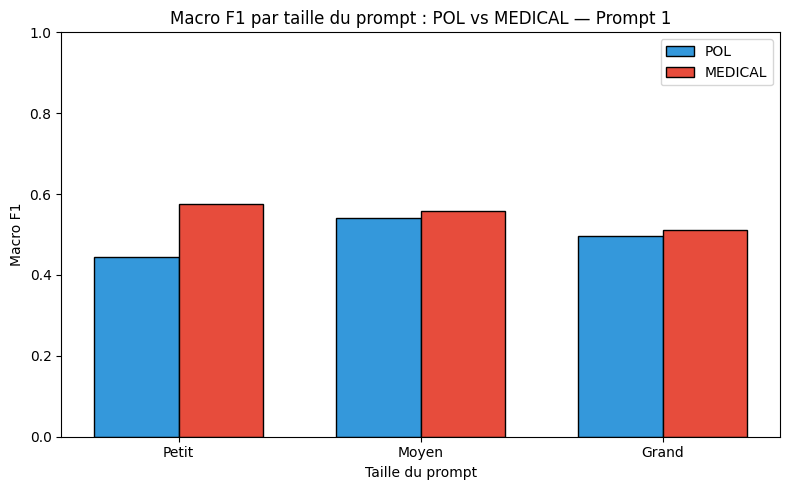

In [11]:
# Bar plot juxtaposé : POL vs MEDICAL par taille
x = np.arange(len(acc_by_size_type))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars_pol = ax.bar(x - width/2, acc_by_size_type["pol"], width, label="POL", color="#3498db", edgecolor="black")
bars_med = ax.bar(x + width/2, acc_by_size_type["medical"], width, label="MEDICAL", color="#e74c3c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(acc_by_size_type.index)
ax.set_ylabel("Macro F1")
ax.set_xlabel("Taille du prompt")
ax.set_title("Macro F1 par taille du prompt : POL vs MEDICAL — Prompt 1")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_macro_f1_taille_pol_vs_medical.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Macro F1 selon le nombre de critères cliniques

Extraction du nombre de critères d'inclusion/exclusion dans le texte des prompts (regex : listes numérotées "1., 2., ..." et conditions avec tiret "-"). Puis **line chart** : en X le nombre de critères, en Y le **Macro F1** ; 3 courbes : Combined, POL, MEDICAL.

In [12]:
def extract_premise_from_user_content(user_content):
    """Extrait le bloc Premise (critères) depuis le contenu utilisateur."""
    if "Hypothesis:" in user_content:
        return user_content.split("Hypothesis:")[0].replace("Premise:", "").strip()
    return user_content.replace("Premise:", "").strip()

def count_criteria(premise_text):
    """
    Compte le nombre de critères cliniques :
    - Numéroté : \\n + espaces + chiffre(s) + point   ex. \\n          1.
    - Puce     : \\n + espaces + tiret + espace(s)    ex. \\n          -
    """
    if not premise_text or not isinstance(premise_text, str):
        return 0
    # Numérotés : newline, espaces, chiffre(s), point
    numbered = re.findall(r"\n\s*\d+\.", premise_text)
    # Puces : newline, espaces, tiret, au moins un espace
    bullet = re.findall(r"\n\s*-\s+", premise_text)
    return len(numbered) + len(bullet)

In [13]:
def load_premises_and_criteria(jsonl_path):
    """Charge pour chaque index le texte de la premise et le nombre de critères."""
    premises = []
    criteria_counts = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            user_content = next(m["content"] for m in obj["messages"] if m["role"] == "user")
            premise = extract_premise_from_user_content(user_content)
            premises.append(premise)
            criteria_counts.append(count_criteria(premise))
    return premises, np.array(criteria_counts)

# On utilise la premise du jeu medical (même critères que POL, seul l'hypothèse change)
premises_medical, criteria_medical = load_premises_and_criteria(path_medical) if os.path.exists(path_medical) else ([], np.array([]))
premises_pol, criteria_pol = load_premises_and_criteria(path_pol) if os.path.exists(path_pol) else ([], np.array([]))
# Pour combined, on a d'abord pol (même index 0..n-1) puis medical (0..n-1) -> critères par index identiques pour un même patient
criteria_per_index = criteria_pol if len(criteria_pol) > 0 else criteria_medical
print("Nombre de critères par prompt (ex.) :", criteria_per_index[:10] if len(criteria_per_index) else "N/A")
print("Min / Max critères :", criteria_per_index.min(), criteria_per_index.max() if len(criteria_per_index) else "N/A")

Nombre de critères par prompt (ex.) : [ 1  2  8 25 24 11 13 35 63  9]
Min / Max critères : 0 109


In [14]:
# Associer le nombre de critères à chaque ligne (index = ligne JSONL)
def get_criteria_for_row(row):
    idx = row["index"]
    stype = row["statement_type"]
    arr = criteria_pol if stype == "pol" else criteria_medical
    if arr is not None and idx < len(arr):
        return arr[idx]
    return np.nan

df_combined_with_size["n_criteria"] = df_combined_with_size.apply(get_criteria_for_row, axis=1)
df_c = df_combined_with_size.dropna(subset=["n_criteria"]).copy()
# Bins de nombre de critères pour une courbe lisible
n_uniq = df_c["n_criteria"].nunique()
n_bins = min(12, max(5, n_uniq // 2))
df_c["criteria_bin"] = pd.cut(df_c["n_criteria"], bins=n_bins, include_lowest=True)
# Centres des bins pour l'axe X
bin_centers = df_c.groupby("criteria_bin")["n_criteria"].mean()
agg_combined = df_c.groupby("criteria_bin").apply(lambda g: macro_f1(g["gold"], g["prediction"]))
agg_pol = df_c[df_c["statement_type"] == "pol"].groupby("criteria_bin").apply(lambda g: macro_f1(g["gold"], g["prediction"]))
agg_medical = df_c[df_c["statement_type"] == "medical"].groupby("criteria_bin").apply(lambda g: macro_f1(g["gold"], g["prediction"]))
# Aligner sur les mêmes bins
all_bins = agg_combined.index
x_vals = [bin_centers[b] for b in all_bins if b in bin_centers.index]
x_vals = bin_centers.reindex(all_bins).values
y_combined = agg_combined.reindex(all_bins).values
y_pol = agg_pol.reindex(all_bins).values
y_medical = agg_medical.reindex(all_bins).values

C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_23828\3081036461.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = df_c.groupby("criteria_bin")["n_criteria"].mean()
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_23828\3081036461.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_combined = df_c.groupby("criteria_bin").apply(lambda g: macro_f1(g["gold"], g["prediction"]))
c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor

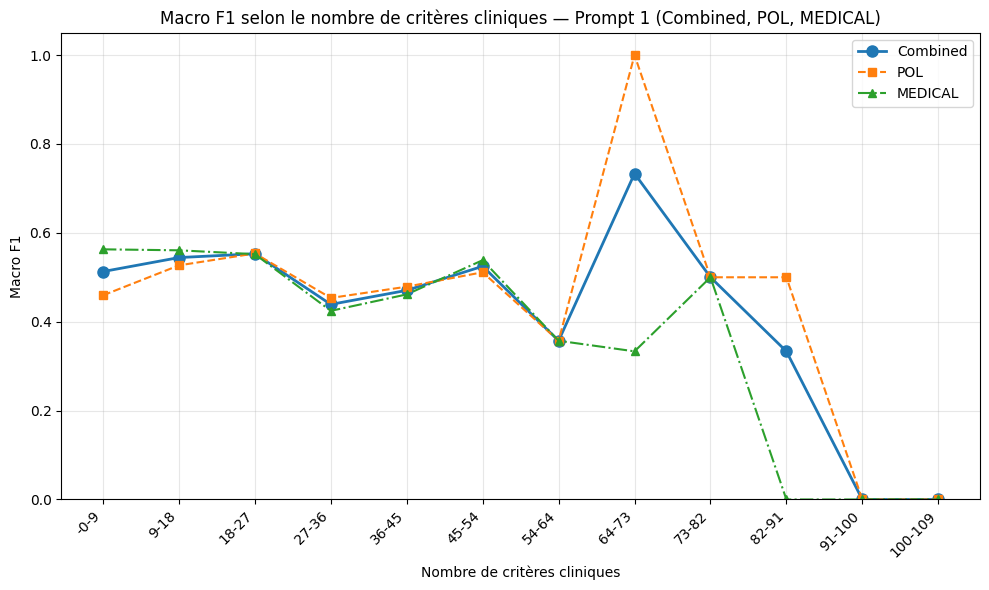

In [15]:
# Line chart : Macro F1 selon le nombre de critères (Combined, POL, MEDICAL)
valid = ~np.isnan(y_combined)
x_plot = np.arange(len(all_bins))[valid]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_plot, y_combined[valid], "o-", label="Combined", linewidth=2, markersize=8)
ax.plot(x_plot, np.where(np.isnan(y_pol[valid]), np.nan, y_pol[valid]), "s--", label="POL", linewidth=1.5, markersize=6)
ax.plot(x_plot, np.where(np.isnan(y_medical[valid]), np.nan, y_medical[valid]), "^-.", label="MEDICAL", linewidth=1.5, markersize=6)
ax.set_xticks(x_plot)
ax.set_xticklabels([f"{all_bins[i].left:.0f}-{all_bins[i].right:.0f}" for i in range(len(all_bins)) if valid[i]], rotation=45, ha="right")
ax.set_xlabel("Nombre de critères cliniques")
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 selon le nombre de critères cliniques — Prompt 1 (Combined, POL, MEDICAL)")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_macro_f1_par_criteres.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Analyse des erreurs communes (Overlap POL / MEDICAL)

Comparaison des erreurs **index par index** entre POL et MEDICAL (même patient = même index dans les deux jeux).  
- Si le modèle se trompe sur les **mêmes** patients dans les deux versions → la **logique médicale** de l'essai est probablement en cause.  
- S'il échoue sur une version mais réussit sur l'autre → le **vocabulaire** (patient vs expert) perturbe le modèle.

In [16]:
# Ensembles d'indices en erreur (même index = même patient)
errors_pol = set(df_pol[~df_pol["is_correct"]]["index"].tolist())
errors_medical = set(df_medical[~df_medical["is_correct"]]["index"].tolist())
overlap = errors_pol & errors_medical
only_pol = errors_pol - errors_medical
only_medical = errors_medical - errors_pol
n_patients = len(df_pol)
print("=== Overlap des erreurs (index = même patient) ===\n")
print(f"Nombre de patients (par jeu) : {n_patients}")
print(f"Erreurs POL     : {len(errors_pol)} ({100*len(errors_pol)/n_patients:.1f}%)")
print(f"Erreurs MEDICAL : {len(errors_medical)} ({100*len(errors_medical)/n_patients:.1f}%)")
print(f"\nErreurs sur les MÊMES patients (overlap) : {len(overlap)}")
print(f"Erreur uniquement en POL     : {len(only_pol)} (réussite en MEDICAL)")
print(f"Erreur uniquement en MEDICAL : {len(only_medical)} (réussite en POL)")
print(f"\nPart des erreurs POL qui sont aussi en erreur en MEDICAL : {100*len(overlap)/len(errors_pol):.1f}%" if errors_pol else "N/A")
print(f"Part des erreurs MEDICAL qui sont aussi en erreur en POL : {100*len(overlap)/len(errors_medical):.1f}%" if errors_medical else "N/A")

=== Overlap des erreurs (index = même patient) ===

Nombre de patients (par jeu) : 1578
Erreurs POL     : 729 (46.2%)
Erreurs MEDICAL : 669 (42.4%)

Erreurs sur les MÊMES patients (overlap) : 564
Erreur uniquement en POL     : 165 (réussite en MEDICAL)
Erreur uniquement en MEDICAL : 105 (réussite en POL)

Part des erreurs POL qui sont aussi en erreur en MEDICAL : 77.4%
Part des erreurs MEDICAL qui sont aussi en erreur en POL : 84.3%


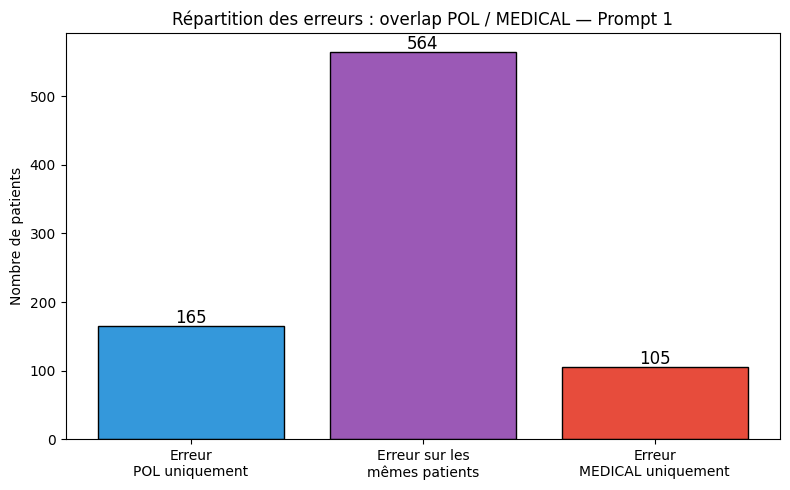

In [17]:
# Visualisation : diagramme de Venn (approché par barres)
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Erreur\nPOL uniquement", "Erreur sur les\nmêmes patients", "Erreur\nMEDICAL uniquement"]
counts = [len(only_pol), len(overlap), len(only_medical)]
colors = ["#3498db", "#9b59b6", "#e74c3c"]
bars = ax.bar(categories, counts, color=colors, edgecolor="black")
ax.set_ylabel("Nombre de patients")
ax.set_title("Répartition des erreurs : overlap POL / MEDICAL — Prompt 1")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, str(c), ha="center", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt1_baseline_erreurs_overlap_pol_medical.png"), dpi=150, bbox_inches="tight")
plt.show()